# Paper plots — KL-diag protagonist (Polar-LoRA)

Locked config: `kl-diag-polar-lora` · PolarExpress PE=8 · Nesterov · β₁=0.9 · δ=1e-4 · k=1 · curvature_beta=0.99 · precond_refresh_every=10 · **precond_method=gram_ns**. AdamW + iMuon baselines; σ=0.0017 noise floor.

In-flight runs render partially (`allow_partial=True`).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'lora_playground').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lora_playground.plotting import compare_variants_figure
from lora_playground.loader import load_runs

# Baselines + protagonist. AdamW MUST be a variant to render (target_label only annotates
# an already-loaded variant, it does not auto-load).
ADAMW = {'optimizer': 'adamw'}
PROTO = {'optimizer': 'kl-diag-polar-lora', 'cw_nesterov': True, 'polar_method': 'polar_express',
         'beta1': 0.9, 'precond_method': 'gram_ns',
         'cw_no_radius': False, 'cw_no_diag_curv': False}  # locked kl-diag config (excludes E2 ablation arms)
# E2 leave-one-out arms (same optimizer; disambiguated by the cw_no_* flags so they
# do NOT contaminate the protagonist panels above):
NOSHAMPOO = {**PROTO, 'cw_no_diag_curv': True}   # -Shampoo: partner-Gram only = iMuon + radius
NORADIUS  = {**PROTO, 'cw_no_radius':   True}    # -radius: plain eta (no operator-norm radius)

def _om(rank):  # common_where for Llama-openmath at a rank
    return dict(model_name='meta-llama/Llama-3.2-1B', lora_r=rank, data_dir=(lambda d: 'openmath' in str(d)))
def _has(where, rank):
    return len(load_runs(where={**where, **{k:v for k,v in _om(rank).items()}}, warn_cross_commit=False)) > 0
def ablation_panel(rank):
    """E2 leave-one-out at one rank; only arms with data render (allow_partial)."""
    arms = {'Polar-LoRA (ours)': PROTO, '-Shampoo (iMuon+radius)': NOSHAMPOO, '-radius (plain eta)': NORADIUS}
    arms = {k: v for k, v in arms.items() if _has(v, rank)}
    fig, _t, sdf = compare_variants_figure(
        arms, common_where=_om(rank), ref_label='Polar-LoRA (ours)',
        logs_root=str(ROOT / 'logs'), sigma_ref=SIGMA, max_steps=9000,
        allow_partial=True, allow_custom_labels=True,
        suptitle=f'E2 ablation - Llama-3.2-1B openmath r{rank}')
    plt.show()
    return sdf
IMUON = {'optimizer': 'imuon-lora'}
SIGMA = 0.0017  # AdamW noise-floor proxy

# The 8-cell E1 set (paper/e1_coverage_fill.md). data_key = substring matched on data_dir.
CELLS = [
    ('OLMo-2-1B opc r256',         'allenai/OLMo-2-0425-1B',     'opc',      256),
    ('Qwen2.5-1.5B opc r256',      'Qwen/Qwen2.5-1.5B',          'opc',      256),
    ('Llama-3.2-1B opc r256',      'meta-llama/Llama-3.2-1B',    'opc',      256),
    ('Llama-3-8B opc r256',        'meta-llama/Meta-Llama-3-8B', 'opc',      256),
    ('Qwen2.5-1.5B bengali r256',  'Qwen/Qwen2.5-1.5B',          'bengali',  256),
    ('Llama-3.2-1B openmath r64',  'meta-llama/Llama-3.2-1B',    'openmath',  64),
    ('Llama-3.2-1B openmath r128', 'meta-llama/Llama-3.2-1B',    'openmath', 128),
    ('Llama-3.2-1B openmath r256', 'meta-llama/Llama-3.2-1B',    'openmath', 256),
]

def panel(name, model, key, rank):
    """AdamW vs Polar-LoRA (ours) vs iMuon at one cell; Δ vs AdamW in σ-units."""
    common = dict(model_name=model, lora_r=rank, data_dir=(lambda d, k=key: k in str(d)))
    fig, _tdf, sdf = compare_variants_figure(
        {'AdamW': ADAMW, 'Polar-LoRA (ours)': PROTO, 'iMuon': IMUON},
        common_where=common, ref_label='AdamW',
        logs_root=str(ROOT / 'logs'), sigma_ref=SIGMA, max_steps=9000,
        allow_partial=True, allow_custom_labels=True, target_label='AdamW',
        suptitle=name,
    )
    plt.show()
    return sdf

## Per-cell panels — AdamW vs Polar-LoRA (ours) vs iMuon

### 1. OLMo-2-1B opc r256

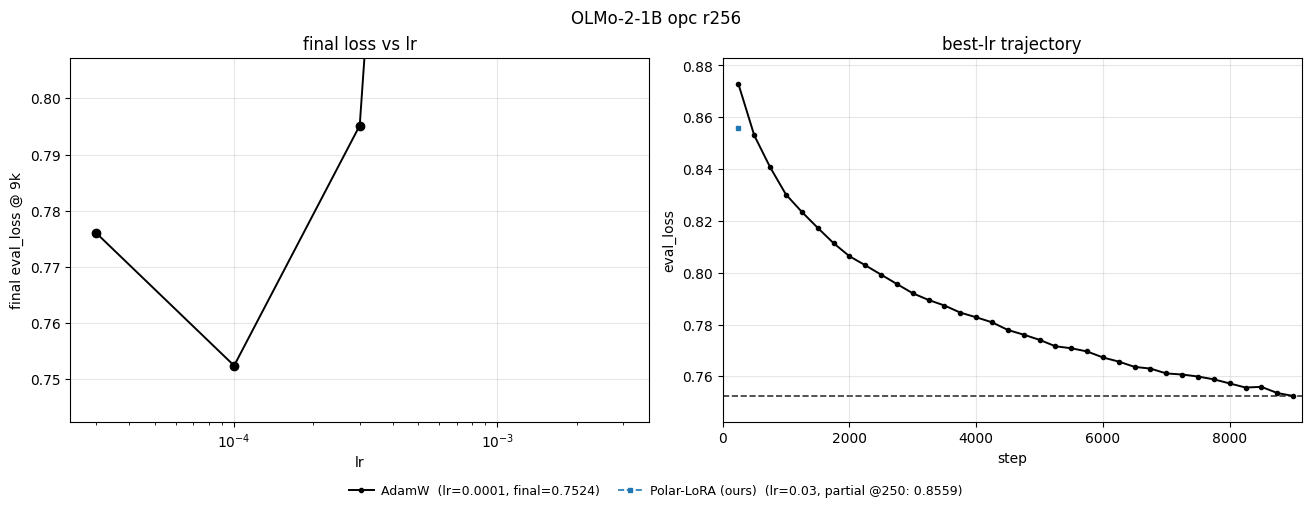

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.752439,None,None


In [2]:
panel('OLMo-2-1B opc r256', 'allenai/OLMo-2-0425-1B', 'opc', 256)

### 2. Qwen2.5-1.5B opc r256

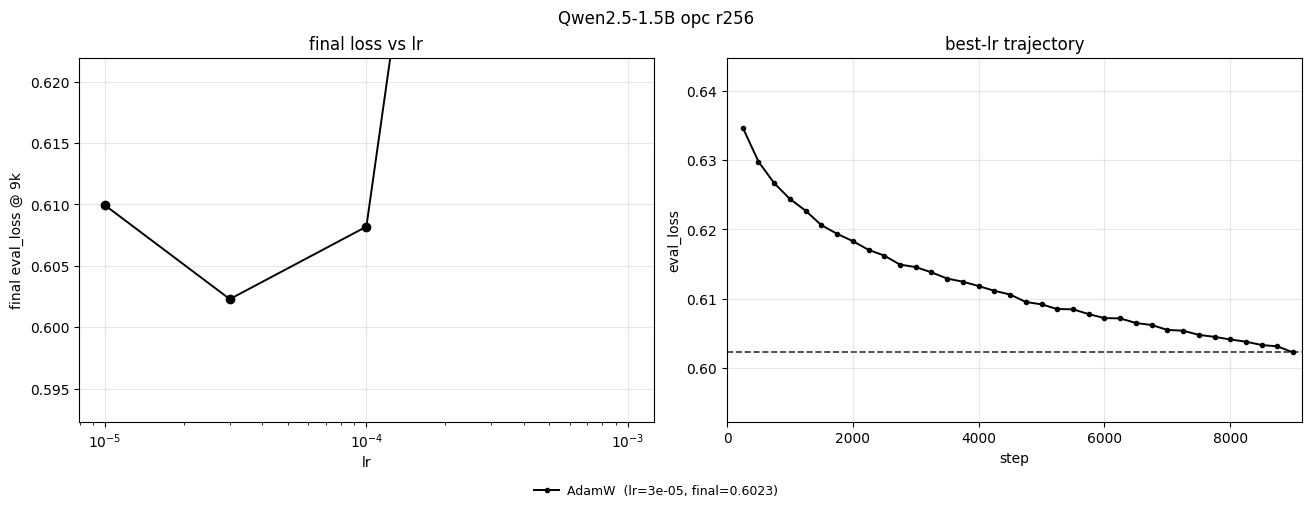

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.00003,0.602292,None,None


In [3]:
panel('Qwen2.5-1.5B opc r256', 'Qwen/Qwen2.5-1.5B', 'opc', 256)

### 3. Llama-3.2-1B opc r256

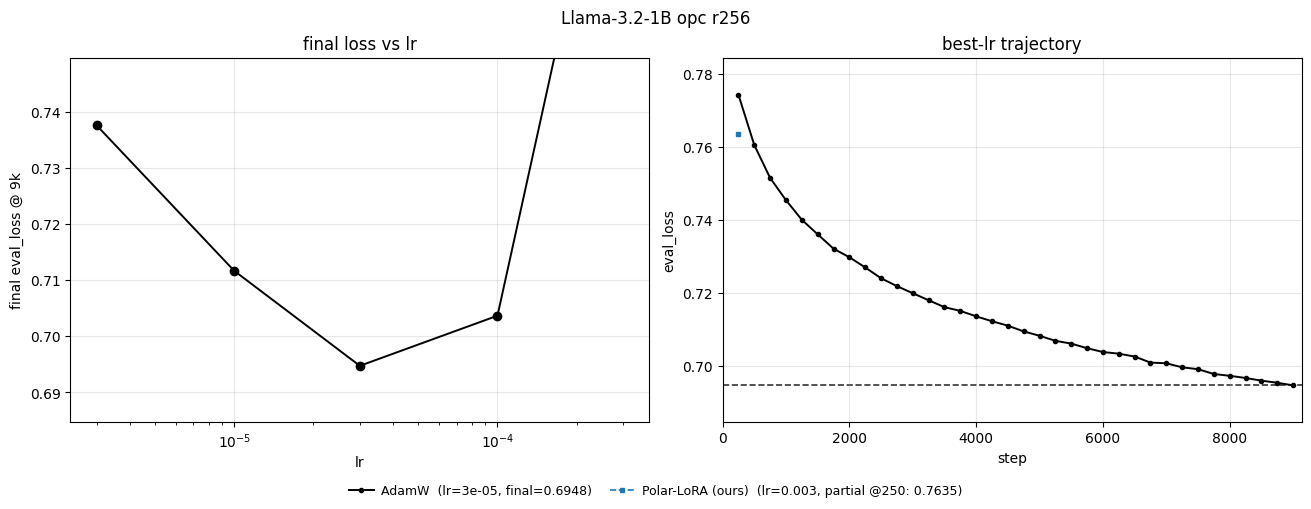

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.00003,0.694754,None,None


In [4]:
panel('Llama-3.2-1B opc r256', 'meta-llama/Llama-3.2-1B', 'opc', 256)

### 4. Llama-3-8B opc r256

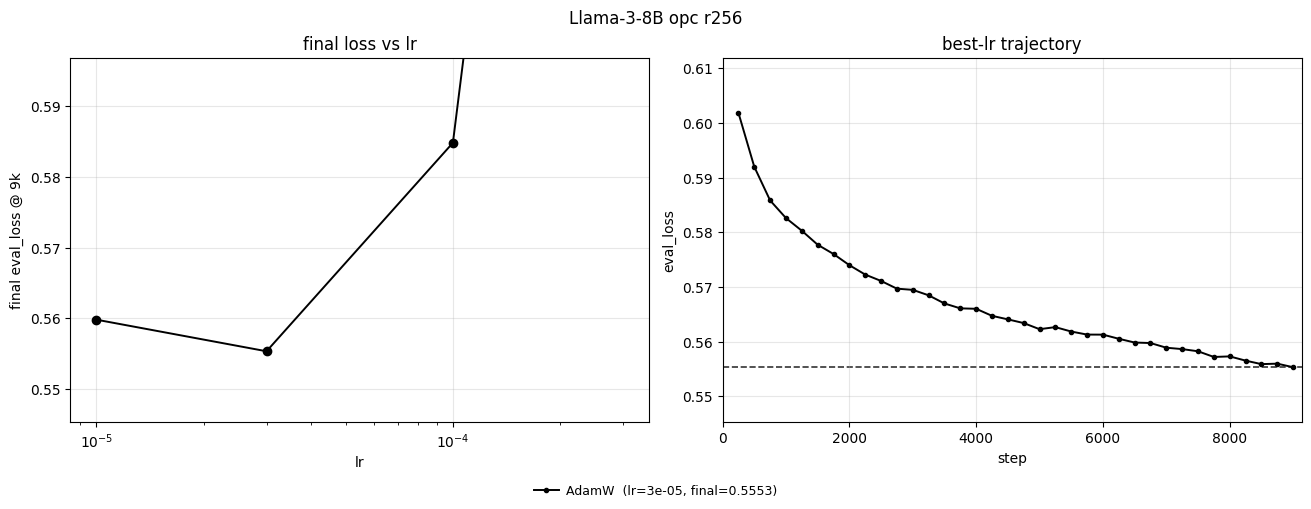

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.00003,0.555303,None,None


In [5]:
panel('Llama-3-8B opc r256', 'meta-llama/Meta-Llama-3-8B', 'opc', 256)

### 5. Qwen2.5-1.5B bengali r256  (OOD pair vs cell 2)

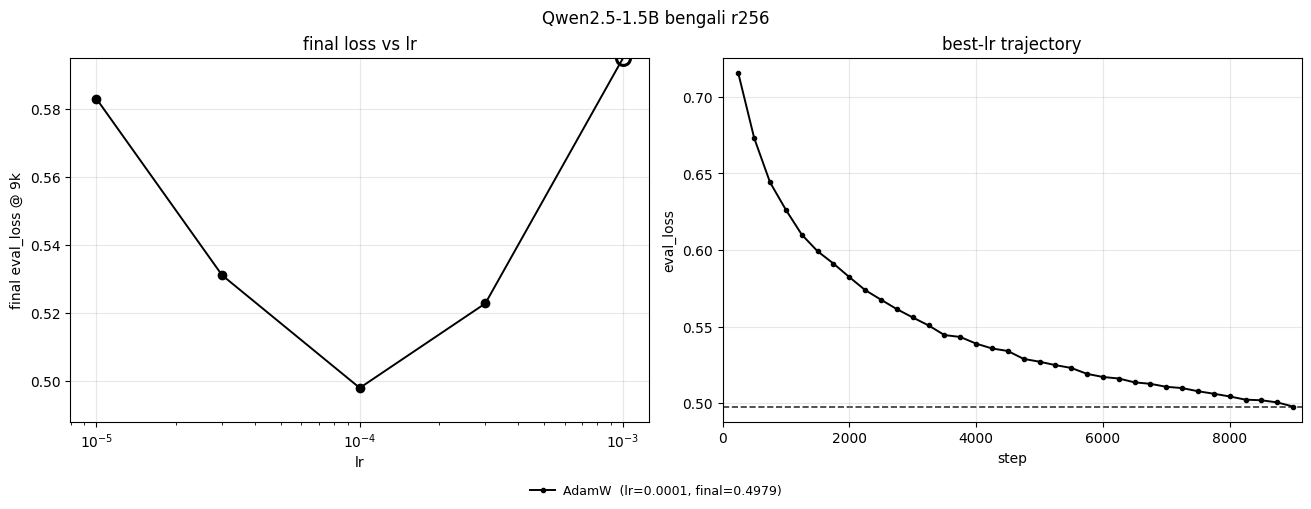

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.497858,None,None


In [6]:
panel('Qwen2.5-1.5B bengali r256', 'Qwen/Qwen2.5-1.5B', 'bengali', 256)

### 6. Llama-3.2-1B openmath r64  (rank ladder)

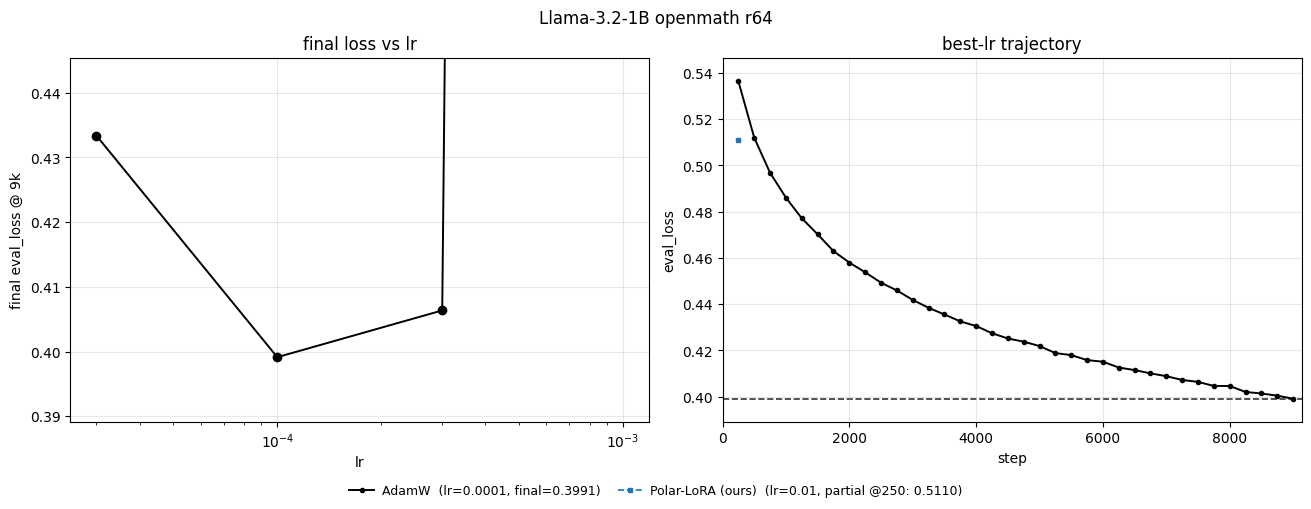

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.399128,None,None


In [7]:
panel('Llama-3.2-1B openmath r64', 'meta-llama/Llama-3.2-1B', 'openmath', 64)

### 7. Llama-3.2-1B openmath r128  (rank ladder)

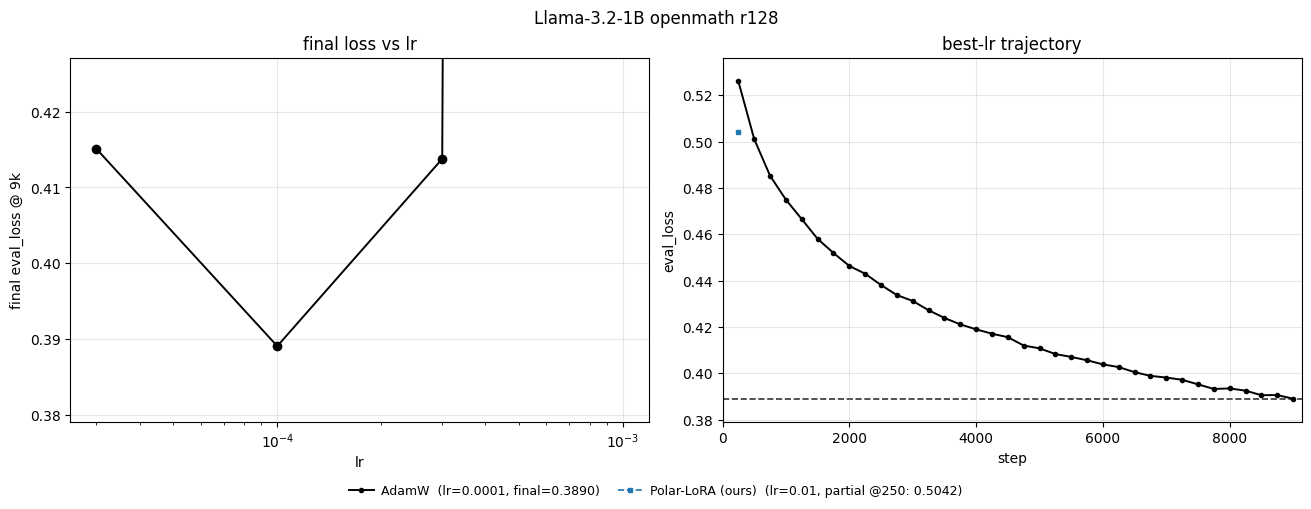

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.389044,None,None


In [8]:
panel('Llama-3.2-1B openmath r128', 'meta-llama/Llama-3.2-1B', 'openmath', 128)

### 8. Llama-3.2-1B openmath r256  (rank ladder)

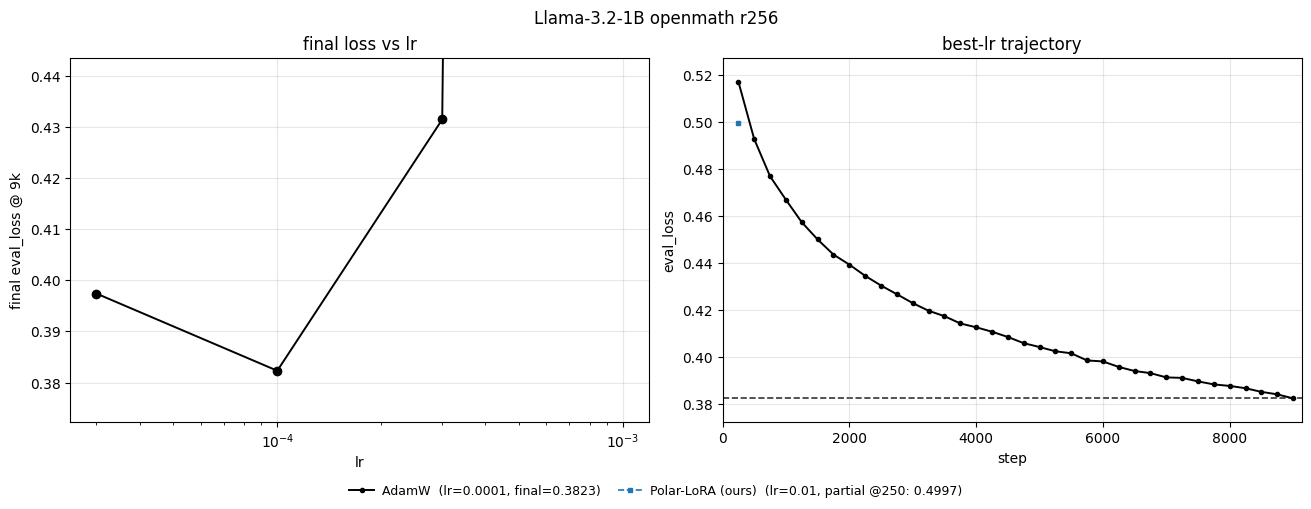

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.382301,None,None


In [9]:
panel('Llama-3.2-1B openmath r256', 'meta-llama/Llama-3.2-1B', 'openmath', 256)

## E2 ablation — Llama-3.2-1B openmath, per rank (leave-one-out)

One panel per rank. Arms: **Polar-LoRA** vs **-Shampoo** (drop diagonal curvature -> iMuon+radius;
the novelty over iMuon) vs **-radius** (drop the operator-norm radius). Delta vs Polar-LoRA in
sigma-units, step-matched (`allow_partial`). -Shampoo was run only at r256; r64/r128 show the
arms that exist. Polar is *not* ablated (cited to the spectral-method literature).

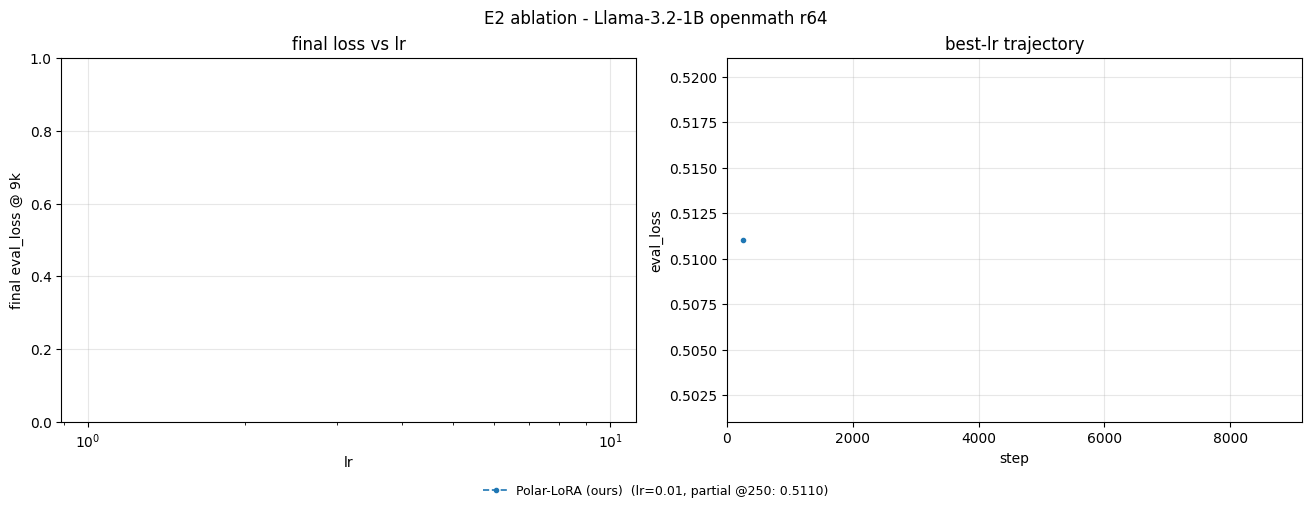

""


In [10]:
ablation_panel(64)

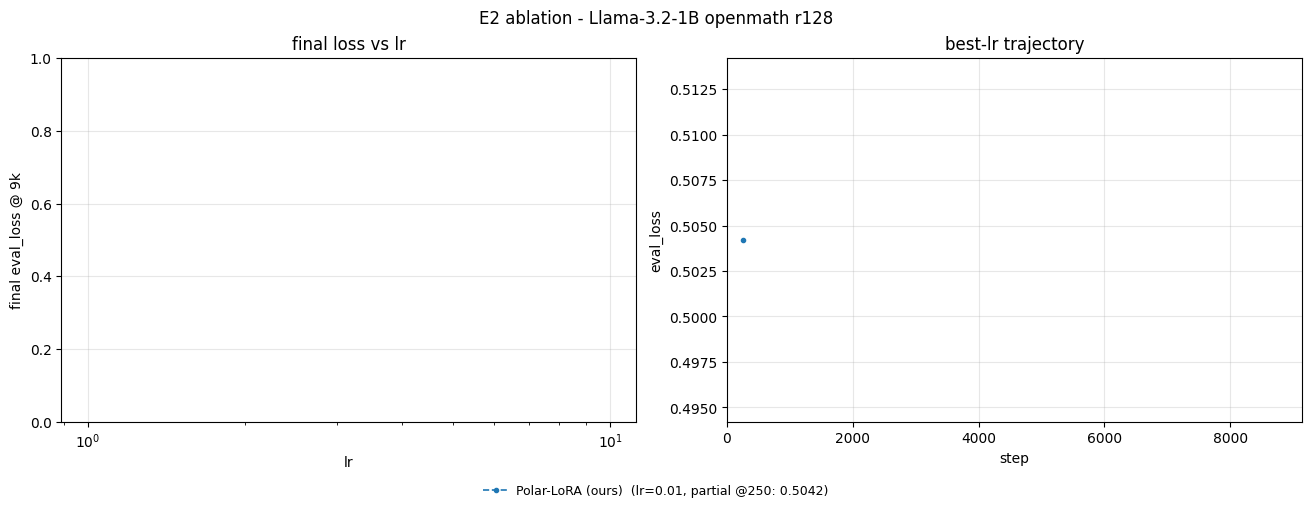

""


In [11]:
ablation_panel(128)

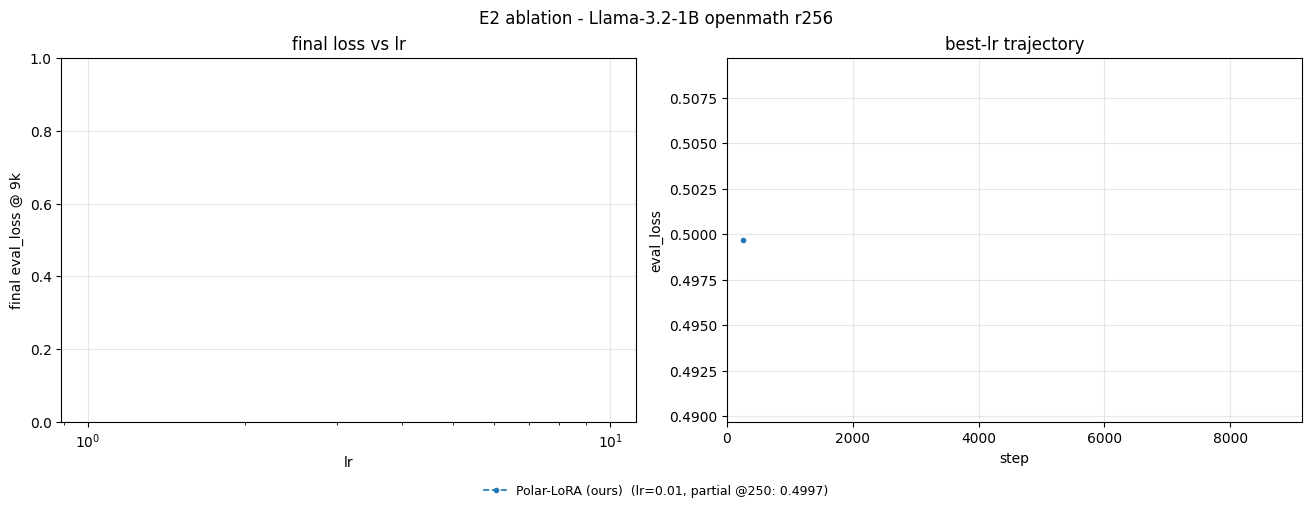

""


In [12]:
ablation_panel(256)

## E2 -radius transfer test - Llama-3.2-1B openmath r64/r128/r256

Does removing the operator-norm radius break lr-stability across rank? For each rank, final
eval loss vs lr: **protagonist** (radius on) vs **-radius** (radius off). If the protagonist's
optimum sits at a fixed lr across ranks while -radius's optimum shifts, the radius is what buys
the rank-stable lr. (No AdamW contrast - AdamW also transfers here; see the analysis notes.)

/tmp/ipykernel_2501504/1224729949.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  if rank==RANKS[0]: ax.set_ylabel('final eval loss (9000 steps)'); ax.legend(fontsize=8)


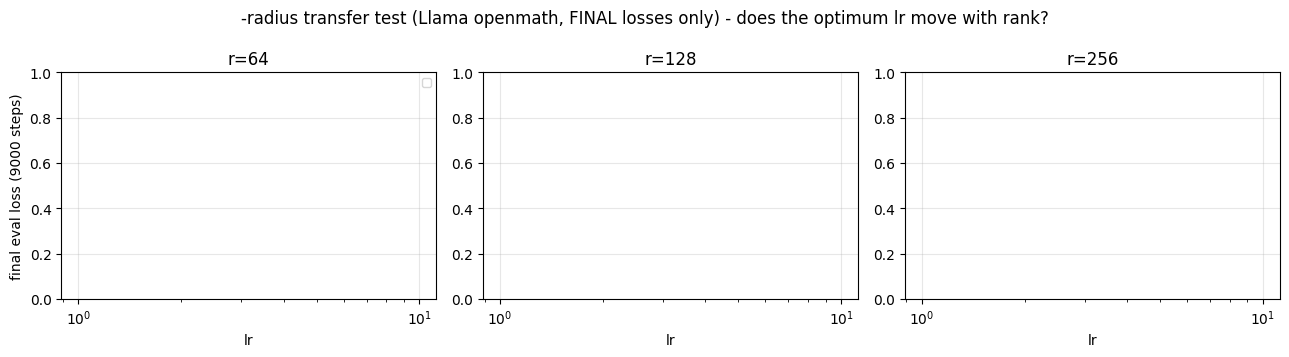

In [13]:
# Transfer test: FINAL-loss-vs-lr per rank, Polar-LoRA vs -radius. Only runs that reached the
# 9000-step horizon count -- a partial run would plot an early-step loss against final losses.
import numpy as np
RANKS=[64,128,256]; HORIZON=9000
def _final_by_lr(where, rank):
    runs=load_runs(where={**where,'lora_r':rank,'model_name':'meta-llama/Llama-3.2-1B',
                          'data_dir':(lambda d:'openmath' in str(d))}, warn_cross_commit=False)
    out={}
    for cfg,evs in runs:
        ev=[(e['step'],e['eval_loss']) for e in (evs or []) if e.get('eval_loss') is not None]
        if not ev or ev[-1][0] < HORIZON: continue   # final losses only (skip partial runs)
        lr=float(cfg.get('lr')); out[lr]=min(out.get(lr,9e9), ev[-1][1])
    return dict(sorted(out.items()))
fig,axes=plt.subplots(1,3,figsize=(13,3.6),sharey=False)
for ax,rank in zip(axes,RANKS):
    for label,where,mk in [('Polar-LoRA',PROTO,'o-'),('-radius',NORADIUS,'s--')]:
        d=_final_by_lr(where,rank)
        if d: ax.plot(list(d),list(d.values()),mk,label=label)
    ax.set_xscale('log'); ax.set_title(f'r={rank}'); ax.set_xlabel('lr'); ax.grid(alpha=.3)
    if rank==RANKS[0]: ax.set_ylabel('final eval loss (9000 steps)'); ax.legend(fontsize=8)
fig.suptitle('-radius transfer test (Llama openmath, FINAL losses only) - does the optimum lr move with rank?')
plt.tight_layout(); plt.show()